In [2]:
try:
    spark.stop()
except:
    pass

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("sf_connector_3x")
    .config("spark.jars.packages",
            "net.snowflake:spark-snowflake_2.12:3.1.5,net.snowflake:snowflake-jdbc:3.16.0")
    .getOrCreate()
)

# Verifica que están ambos JARs
jlist = spark.sparkContext._jsc.sc().listJars()
print("\n".join([str(jlist.apply(i)) for i in range(jlist.size())]))


spark://0.0.0.0:43217/jars/commons-pool_commons-pool-1.6.jar
spark://0.0.0.0:43217/jars/org.apache.commons_commons-lang3-3.14.0.jar
spark://0.0.0.0:43217/jars/commons-codec_commons-codec-1.17.0.jar
spark://0.0.0.0:43217/jars/com.github.luben_zstd-jni-1.5.6-6.jar
spark://0.0.0.0:43217/jars/org.apache.parquet_parquet-format-structures-1.15.2.jar
spark://0.0.0.0:43217/jars/org.apache.parquet_parquet-jackson-1.15.2.jar
spark://0.0.0.0:43217/jars/javax.annotation_javax.annotation-api-1.3.2.jar
spark://0.0.0.0:43217/jars/org.apache.parquet_parquet-common-1.15.2.jar
spark://0.0.0.0:43217/jars/org.apache.parquet_parquet-hadoop-1.15.2.jar
spark://0.0.0.0:43217/jars/com.fasterxml.jackson.core_jackson-databind-2.14.3.jar
spark://0.0.0.0:43217/jars/org.apache.avro_avro-1.11.4.jar
spark://0.0.0.0:43217/jars/commons-io_commons-io-2.16.1.jar
spark://0.0.0.0:43217/jars/org.apache.parquet_parquet-encoding-1.15.2.jar
spark://0.0.0.0:43217/jars/org.apache.parquet_parquet-column-1.15.2.jar
spark://0.0.0.0

In [3]:
!pip install --quiet snowflake-connector-python snowflake-snowpark-python pyarrow pandas requests


In [9]:
import os

os.environ["SNOWFLAKE_ACCOUNT"]   = "KDPRMVC-TCC66118"  # en minúsculas
os.environ["SNOWFLAKE_USER"]      = "ERICKDS1017"
os.environ["SNOWFLAKE_PASSWORD"]  = "Snowdansuar1017$"
os.environ["SNOWFLAKE_WAREHOUSE"] = "WH_DM_P3"

os.environ["SNOWFLAKE_ROLE"]      = "R_DM_P3"
os.environ["SNOWFLAKE_DATABASE"]  = "DB_TLC"
os.environ["SNOWFLAKE_SCHEMA"]    = "RAW"

print("OK USER?", bool(os.getenv("SNOWFLAKE_USER")), "OK PASS?", bool(os.getenv("SNOWFLAKE_PASSWORD")))


OK USER? True OK PASS? True


In [10]:
from snowflake.snowpark import Session

conn = {
  "account":   os.getenv("SNOWFLAKE_ACCOUNT"),
  "user":      os.getenv("SNOWFLAKE_USER"),
  "password":  os.getenv("SNOWFLAKE_PASSWORD"),
  "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE"),
  "role":      os.getenv("SNOWFLAKE_ROLE"),
  "database":  os.getenv("SNOWFLAKE_DATABASE"),
  "schema":    os.getenv("SNOWFLAKE_SCHEMA"),
}
session = Session.builder.configs(conn).create()


session.sql("SELECT CURRENT_ROLE() role, CURRENT_WAREHOUSE() wh, CURRENT_DATABASE() db, CURRENT_SCHEMA() sch").show()


---------------------------------------
|"ROLE"   |"WH"      |"DB"    |"SCH"  |
---------------------------------------
|R_DM_P3  |WH_DM_P3  |DB_TLC  |RAW    |
---------------------------------------



In [14]:
import os, requests, datetime as dt

def download_parquet(service: str, year: int, month: int) -> str:
    mm = f"{month:02d}"
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{service}_tripdata_{year}-{mm}.parquet"
    local = f"/home/jovyan/work/{service}_{year}-{mm}.parquet"
    r = requests.get(url, stream=True, timeout=120); r.raise_for_status()
    with open(local, "wb") as f:
        for chunk in r.iter_content(1024*1024):
            if chunk: f.write(chunk)
    return local

def ensure_stage():
    session.sql("CREATE STAGE IF NOT EXISTS STG_HTTP_RAW FILE_FORMAT=(TYPE=PARQUET)").collect()

def put_to_stage(local_path: str):
    session.file.put(f"file://{local_path}", "@STG_HTTP_RAW", auto_compress=False, overwrite=True)

def create_staging_table(service: str, y: int, m: int):
    if service == "yellow":
        like_table = "TRIPS_YELLOW"
        stg = f"STG_YELLOW_{y}{m:02d}"
    else:
        like_table = "TRIPS_GREEN"
        stg = f"STG_GREEN_{y}{m:02d}"
    session.sql(f"CREATE OR REPLACE TABLE {stg} LIKE {like_table}").collect()
    return stg

def copy_into_staging(service: str, y: int, m: int, filename: str):
    stg = f"STG_YELLOW_{y}{m:02d}" if service=="yellow" else f"STG_GREEN_{y}{m:02d}"
    # COPY con inferencia parquet
    session.sql(f"""
        COPY INTO {stg}
        FROM (SELECT * FROM @STG_HTTP_RAW/{filename})
        FILE_FORMAT=(TYPE=PARQUET)
        ON_ERROR=CONTINUE
    """).collect()
    return stg

def insert_audit(run_id: str, service: str, y: int, m: int, rows: int, source_path: str):
    session.sql(f"""
        INSERT INTO AUDIT_LOADS (run_id, service_type, source_year, source_month, started_at_utc, finished_at_utc, rows_written, source_path)
        VALUES ('{run_id}','{service}',{y},{m},CURRENT_TIMESTAMP(),CURRENT_TIMESTAMP(),{rows},'{source_path}')
    """).collect()


In [15]:
from snowflake.snowpark import Session
import os

conn = {
  "account":   os.getenv("SNOWFLAKE_ACCOUNT"),
  "user":      os.getenv("SNOWFLAKE_USER"),
  "password":  os.getenv("SNOWFLAKE_PASSWORD"),
  "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE", "WH_DM_P3"),
  "role":      os.getenv("SNOWFLAKE_ROLE", "R_DM_P3"),
  "database":  os.getenv("SNOWFLAKE_DATABASE", "DB_TLC"),
  "schema":    os.getenv("SNOWFLAKE_SCHEMA", "RAW"),
}
session = Session.builder.configs(conn).create()

# Fijar contexto por si acaso
session.sql("USE ROLE R_DM_P3").collect()
session.sql("USE WAREHOUSE WH_DM_P3").collect()
session.sql("USE DATABASE DB_TLC").collect()
session.sql("USE SCHEMA RAW").collect()

session.sql("SELECT CURRENT_ROLE(), CURRENT_WAREHOUSE(), CURRENT_DATABASE(), CURRENT_SCHEMA()").show()


----------------------------------------------------------------------------------------
|"CURRENT_ROLE()"  |"CURRENT_WAREHOUSE()"  |"CURRENT_DATABASE()"  |"CURRENT_SCHEMA()"  |
----------------------------------------------------------------------------------------
|R_DM_P3           |WH_DM_P3               |DB_TLC                |RAW                 |
----------------------------------------------------------------------------------------



In [20]:
import os, requests, datetime as dt

def download_parquet(service: str, year: int, month: int) -> str:
    mm = f"{month:02d}"
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{service}_tripdata_{year}-{mm}.parquet"
    local = f"/home/jovyan/work/{service}_{year}-{mm}.parquet"
    print(f"Descargando {url} -> {local}")
    r = requests.get(url, stream=True, timeout=120); r.raise_for_status()
    with open(local, "wb") as f:
        for chunk in r.iter_content(1024*1024):
            if chunk: f.write(chunk)
    sz = os.path.getsize(local)
    print(f"OK descarga ({sz/1024/1024:.2f} MB)")
    return local

def put_to_user_stage(local_path: str):
    # @~ es el "user stage" y NO requiere CREATE STAGE en el schema
    print(f"Subiendo a user stage: @~/{os.path.basename(local_path)}")
    res = session.file.put(f"file://{local_path}", "@~", auto_compress=False, overwrite=True)
    print(res)

def ensure_staging_table(service: str, y: int, m: int) -> str:
    stg = f"STG_YELLOW_{y}{m:02d}" if service=="yellow" else f"STG_GREEN_{y}{m:02d}"
    like_table = "TRIPS_YELLOW" if service=="yellow" else "TRIPS_GREEN"
    print(f"Creando tabla staging: {stg} LIKE {like_table}")
    session.sql(f"CREATE OR REPLACE TABLE {stg} LIKE {like_table}").collect()
    return stg

def copy_into_from_user_stage(service: str, y: int, m: int, filename: str) -> int:
    stg = f"STG_YELLOW_{y}{m:02d}" if service=="yellow" else f"STG_GREEN_{y}{m:02d}"
    print(f"COPY INTO {stg} FROM @~/{filename}")
    session.sql(f"""
        COPY INTO {stg}
        FROM (SELECT * FROM @~/{filename})
        FILE_FORMAT=(TYPE=PARQUET)
        ON_ERROR=CONTINUE
    """).collect()
    rows = session.sql(f"SELECT COUNT(*) c FROM {stg}").collect()[0]["C"]
    print(f"✅ {stg}: {rows} filas")
    return rows

def insert_audit(run_id: str, service: str, y: int, m: int, rows: int, source_url: str):
    print("Insertando auditoría…")
    session.sql(f"""
        INSERT INTO AUDIT_LOADS (run_id, service_type, source_year, source_month, started_at_utc, finished_at_utc, rows_written, source_path)
        VALUES ('{run_id}','{service}',{y},{m},CURRENT_TIMESTAMP(),CURRENT_TIMESTAMP(),{rows},'{source_url}')
    """).collect()
    print("✅ Auditoría ok")


In [22]:
# Reintento de carga a staging con "MATCH_BY_COLUMN_NAME" y luego UPDATE de metadatos
service, year, month = "yellow", 2022, 1
run_id = f"ingesta_fix_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
mm = f"{month:02d}"
source_url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{service}_tripdata_{year}-{mm}.parquet"

# 1) Descarga (si ya descargaste antes, se reutiliza el archivo)
local = f"/home/jovyan/work/{service}_{year}-{mm}.parquet"
if not os.path.exists(local):
    local = download_parquet(service, year, month)
else:
    print(f"Usando archivo local: {local}")

# 2) Sube al user stage @~
put_to_user_stage(local)

# 3) Crea/reemplaza la tabla staging con el esquema correcto
stg = ensure_staging_table(service, year, month)

# 4) COPY con match por nombre de columna (case-insensitive) desde Parquet
print("COPY (match by column name)")
session.sql(f"""
    COPY INTO {stg}
    FROM @~/{os.path.basename(local)}
    FILE_FORMAT=(TYPE=PARQUET)
    MATCH_BY_COLUMN_NAME=CASE_INSENSITIVE
    ON_ERROR=CONTINUE
""").collect()

# 5) Completa columnas de metadatos que no vienen en el Parquet
print("UPDATE metadatos (run_id, service_type, year/month, timestamps, source_path)")
session.sql(f"""
    UPDATE {stg}
    SET
      run_id          = '{run_id}',
      service_type    = '{service}',
      source_year     = {year},
      source_month    = {month},
      ingested_at_utc = CURRENT_TIMESTAMP(),
      source_path     = '{source_url}'
""").collect()

# 6) Verifica filas
res = session.sql(f"SELECT COUNT(*) c FROM {stg}").collect()[0]["C"]
print(f"✅ RAW.{stg}: {res} filas listísimas para MERGE")


Usando archivo local: /home/jovyan/work/yellow_2022-01.parquet
Subiendo a user stage: @~/yellow_2022-01.parquet
[PutResult(source='yellow_2022-01.parquet', target='yellow_2022-01.parquet', source_size=38139949, target_size=38139952, source_compression='PARQUET', target_compression='PARQUET', status='UPLOADED', message='')]
Creando tabla staging: STG_YELLOW_202201 LIKE TRIPS_YELLOW
COPY (match by column name)
UPDATE metadatos (run_id, service_type, year/month, timestamps, source_path)
✅ RAW.STG_YELLOW_202201: 2463931 filas listísimas para MERGE


In [23]:
# GREEN 2022-01 → staging via user stage, con metadatos
service, year, month = "green", 2022, 1
run_id = f"ingesta_fix_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
mm = f"{month:02d}"
source_url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{service}_tripdata_{year}-{mm}.parquet"

local = f"/home/jovyan/work/{service}_{year}-{mm}.parquet"
if not os.path.exists(local):
    local = download_parquet(service, year, month)
else:
    print(f"Usando archivo local: {local}")

put_to_user_stage(local)
stg = ensure_staging_table(service, year, month)

print("COPY (match by column name)")
session.sql(f"""
    COPY INTO {stg}
    FROM @~/{os.path.basename(local)}
    FILE_FORMAT=(TYPE=PARQUET)
    MATCH_BY_COLUMN_NAME=CASE_INSENSITIVE
    ON_ERROR=CONTINUE
""").collect()

print("UPDATE metadatos")
session.sql(f"""
    UPDATE {stg}
    SET
      run_id          = '{run_id}',
      service_type    = '{service}',
      source_year     = {year},
      source_month    = {month},
      ingested_at_utc = CURRENT_TIMESTAMP(),
      source_path     = '{source_url}'
""").collect()

res = session.sql(f"SELECT COUNT(*) c FROM {stg}").collect()[0]["C"]
print(f"✅ RAW.{stg}: {res} filas listísimas para MERGE")


Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet -> /home/jovyan/work/green_2022-01.parquet
OK descarga (1.20 MB)
Subiendo a user stage: @~/green_2022-01.parquet
[PutResult(source='green_2022-01.parquet', target='green_2022-01.parquet', source_size=1254291, target_size=1254304, source_compression='PARQUET', target_compression='PARQUET', status='UPLOADED', message='')]
Creando tabla staging: STG_GREEN_202201 LIKE TRIPS_GREEN
COPY (match by column name)
UPDATE metadatos
✅ RAW.STG_GREEN_202201: 62495 filas listísimas para MERGE


In [25]:
def load_month(service: str, year: int, month: int):
    mm = f"{month:02d}"
    run_id = f"ingesta_{service}_{year}{mm}"
    source_url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{service}_tripdata_{year}-{mm}.parquet"
    local = f"/home/jovyan/work/{service}_{year}-{mm}.parquet"
    if not os.path.exists(local):
        download_parquet(service, year, month)
    put_to_user_stage(local)
    stg = ensure_staging_table(service, year, month)
    session.sql(f"""
        COPY INTO {stg}
        FROM @~/{os.path.basename(local)}
        FILE_FORMAT=(TYPE=PARQUET)
        MATCH_BY_COLUMN_NAME=CASE_INSENSITIVE
        ON_ERROR=CONTINUE
    """).collect()
    session.sql(f"""
        UPDATE {stg}
        SET run_id='{run_id}', service_type='{service}', source_year={year}, source_month={month},
            ingested_at_utc=CURRENT_TIMESTAMP(), source_path='{source_url}'
    """).collect()
    rows = session.sql(f"SELECT COUNT(*) c FROM {stg}").collect()[0]["C"]
    print(f"✅ RAW.{stg}: {rows} filas")
    return stg

# Ejemplos:
# load_month("yellow", 2022, 2)
# load_month("green",  2022, 2)


In [26]:
load_month("yellow", 2022, 2)

Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-02.parquet -> /home/jovyan/work/yellow_2022-02.parquet
OK descarga (43.50 MB)
Subiendo a user stage: @~/yellow_2022-02.parquet
[PutResult(source='yellow_2022-02.parquet', target='yellow_2022-02.parquet', source_size=45616512, target_size=45616528, source_compression='PARQUET', target_compression='PARQUET', status='UPLOADED', message='')]
Creando tabla staging: STG_YELLOW_202202 LIKE TRIPS_YELLOW
✅ RAW.STG_YELLOW_202202: 2979431 filas


'STG_YELLOW_202202'

In [27]:
# ==== CARGA MASIVA 10 AÑOS (2016–2025) YELLOW + GREEN ====
# Requisitos previos en este notebook:
# - 'session' (Snowpark) ya conectado con ROLE/WHS/DB/SCHEMA correctos (R_DM_P3, WH_DM_P3, DB_TLC, RAW)
# - Funciones: download_parquet, put_to_user_stage, ensure_staging_table, insert_audit
#   (si las definiste como en pasos anteriores).
# Si no las tienes, vuelve a ejecutar las celdas donde las definimos.

import os, datetime as dt

SERVICES = ["yellow", "green"]
START_YEAR = 2016
END_YEAR   = 2025         # inclusive (10 años: 2016..2025)
MONTHS     = list(range(1, 13))
DO_MERGE   = True         # deja True para cargar a TRIPS_* automáticamente

def merge_sql(service:str, y:int, m:int)->str:
    ym = f"{y}{m:02d}"
    if service == "yellow":
        return f"""
MERGE INTO DB_TLC.RAW.TRIPS_YELLOW AS tgt
USING DB_TLC.RAW.STG_YELLOW_{ym} AS src
ON  tgt.tpep_pickup_datetime = src.tpep_pickup_datetime
AND tgt.tpep_dropoff_datetime = src.tpep_dropoff_datetime
AND tgt.pu_location_id       = src.pu_location_id
AND tgt.do_location_id       = src.do_location_id
AND tgt.vendor_id            = src.vendor_id
WHEN MATCHED THEN UPDATE SET
    run_id                  = src.run_id,
    ingested_at_utc         = src.ingested_at_utc,
    service_type            = src.service_type,
    source_year             = src.source_year,
    source_month            = src.source_month,
    source_path             = src.source_path,
    fare_amount             = src.fare_amount,
    extra                   = src.extra,
    mta_tax                 = src.mta_tax,
    tip_amount              = src.tip_amount,
    tolls_amount            = src.tolls_amount,
    improvement_surcharge   = src.improvement_surcharge,
    congestion_surcharge    = src.congestion_surcharge,
    airport_fee             = src.airport_fee,
    total_amount            = src.total_amount
WHEN NOT MATCHED THEN INSERT (
    tpep_pickup_datetime, tpep_dropoff_datetime, pu_location_id, do_location_id,
    passenger_count, trip_distance, rate_code_id, store_and_fwd_flag, payment_type,
    fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge,
    congestion_surcharge, airport_fee, total_amount,
    vendor_id, run_id, service_type, source_year, source_month, ingested_at_utc, source_path
) VALUES (
    src.tpep_pickup_datetime, src.tpep_dropoff_datetime, src.pu_location_id, src.do_location_id,
    src.passenger_count, src.trip_distance, src.rate_code_id, src.store_and_fwd_flag, src.payment_type,
    src.fare_amount, src.extra, src.mta_tax, src.tip_amount, src.tolls_amount, src.improvement_surcharge,
    src.congestion_surcharge, src.airport_fee, src.total_amount,
    src.vendor_id, src.run_id, src.service_type, src.source_year, src.source_month, src.ingested_at_utc, src.source_path
);"""
    else:
        return f"""
MERGE INTO DB_TLC.RAW.TRIPS_GREEN AS tgt
USING DB_TLC.RAW.STG_GREEN_{ym} AS src
ON  tgt.lpep_pickup_datetime = src.lpep_pickup_datetime
AND tgt.lpep_dropoff_datetime = src.lpep_dropoff_datetime
AND tgt.pu_location_id       = src.pu_location_id
AND tgt.do_location_id       = src.do_location_id
AND tgt.vendor_id            = src.vendor_id
WHEN MATCHED THEN UPDATE SET
    run_id                  = src.run_id,
    ingested_at_utc         = src.ingested_at_utc,
    service_type            = src.service_type,
    source_year             = src.source_year,
    source_month            = src.source_month,
    source_path             = src.source_path,
    trip_type               = src.trip_type,
    fare_amount             = src.fare_amount,
    extra                   = src.extra,
    mta_tax                 = src.mta_tax,
    tip_amount              = src.tip_amount,
    tolls_amount            = src.tolls_amount,
    improvement_surcharge   = src.improvement_surcharge,
    congestion_surcharge    = src.congestion_surcharge,
    total_amount            = src.total_amount
WHEN NOT MATCHED THEN INSERT (
    lpep_pickup_datetime, lpep_dropoff_datetime, pu_location_id, do_location_id,
    passenger_count, trip_distance, rate_code_id, store_and_fwd_flag, payment_type,
    fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge,
    congestion_surcharge, total_amount, trip_type,
    vendor_id, run_id, service_type, source_year, source_month, ingested_at_utc, source_path
) VALUES (
    src.lpep_pickup_datetime, src.lpep_dropoff_datetime, src.pu_location_id, src.do_location_id,
    src.passenger_count, src.trip_distance, src.rate_code_id, src.store_and_fwd_flag, src.payment_type,
    src.fare_amount, src.extra, src.mta_tax, src.tip_amount, src.tolls_amount, src.improvement_surcharge,
    src.congestion_surcharge, src.total_amount, src.trip_type,
    src.vendor_id, src.run_id, src.service_type, src.source_year, src.source_month, src.ingested_at_utc, src.source_path
);"""

def run_massive_load():
    ok, skipped, failed = [], [], []
    for svc in SERVICES:
        for y in range(START_YEAR, END_YEAR+1):
            for m in MONTHS:
                mm = f"{m:02d}"
                url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{svc}_tripdata_{y}-{mm}.parquet"
                local = f"/home/jovyan/work/{svc}_{y}-{mm}.parquet"
                run_id = f"backfill_{svc}_{y}{mm}"
                print(f"\n==== {svc.upper()} {y}-{mm} ====")
                try:
                    # 1) Descargar (si ya existe, reutiliza)
                    if not os.path.exists(local):
                        print("Descargando:", url)
                        download_parquet(svc, y, m)
                    else:
                        print("Usando archivo local:", local)

                    # 2) Subir al user stage
                    put_to_user_stage(local)

                    # 3) Crear STG LIKE TRIPS_*
                    stg = ensure_staging_table(svc, y, m)

                    # 4) COPY por nombre de columna
                    session.sql(f"""
                        COPY INTO {stg}
                        FROM @~/{os.path.basename(local)}
                        FILE_FORMAT=(TYPE=PARQUET)
                        MATCH_BY_COLUMN_NAME=CASE_INSENSITIVE
                        ON_ERROR=CONTINUE
                    """).collect()

                    # 5) UPDATE metadatos
                    session.sql(f"""
                        UPDATE {stg}
                        SET
                          run_id          = '{run_id}',
                          service_type    = '{svc}',
                          source_year     = {y},
                          source_month    = {m},
                          ingested_at_utc = CURRENT_TIMESTAMP(),
                          source_path     = '{url}'
                    """).collect()

                    # 6) Conteo + auditoría
                    rows = session.sql(f"SELECT COUNT(*) c FROM {stg}").collect()[0]["C"]
                    insert_audit(run_id, svc, y, m, rows, url)
                    print(f"✅ STG cargado: RAW.{stg} -> {rows} filas + auditoría")

                    # 7) MERGE a TRIPS_* (opcional)
                    if DO_MERGE:
                        session.sql(merge_sql(svc, y, m)).collect()
                        print("✅ MERGE aplicado a TRIPS_*")

                    ok.append((svc, y, m, rows))
                except Exception as e:
                    msg = str(e)
                    if "404" in msg or "Not Found" in msg:
                        print("· No disponible, se omite:", url)
                        skipped.append((svc, y, m))
                    else:
                        print("❌ Error:", msg[:300])
                        failed.append((svc, y, m, msg[:300]))

    print("\n===== RESUMEN =====")
    print(f"OK: {len(ok)} meses")
    print(f"Skipped (no disponible): {len(skipped)} meses")
    print(f"Failed (errores): {len(failed)} meses")
    return {"ok": ok, "skipped": skipped, "failed": failed}

summary = run_massive_load()
summary



==== YELLOW 2016-01 ====
Descargando: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2016-01.parquet
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2016-01.parquet -> /home/jovyan/work/yellow_2016-01.parquet
OK descarga (144.24 MB)
Subiendo a user stage: @~/yellow_2016-01.parquet
[PutResult(source='yellow_2016-01.parquet', target='yellow_2016-01.parquet', source_size=151251087, target_size=151251088, source_compression='PARQUET', target_compression='PARQUET', status='UPLOADED', message='')]
Creando tabla staging: STG_YELLOW_201601 LIKE TRIPS_YELLOW
Insertando auditoría…
✅ Auditoría ok
✅ STG cargado: RAW.STG_YELLOW_201601 -> 10905067 filas + auditoría
✅ MERGE aplicado a TRIPS_*

==== YELLOW 2016-02 ====
Descargando: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2016-02.parquet
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2016-02.parquet -> /home/jovyan/work/yellow_2016-02.parquet
OK descarga 

Insertando auditoría…
✅ Auditoría ok
✅ STG cargado: RAW.STG_YELLOW_201705 -> 10102127 filas + auditoría
✅ MERGE aplicado a TRIPS_*

==== YELLOW 2017-06 ====
Descargando: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2017-06.parquet
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2017-06.parquet -> /home/jovyan/work/yellow_2017-06.parquet
OK descarga (129.21 MB)
Subiendo a user stage: @~/yellow_2017-06.parquet
[PutResult(source='yellow_2017-06.parquet', target='yellow_2017-06.parquet', source_size=135482101, target_size=135482112, source_compression='PARQUET', target_compression='PARQUET', status='UPLOADED', message='')]
Creando tabla staging: STG_YELLOW_201706 LIKE TRIPS_YELLOW
Insertando auditoría…
✅ Auditoría ok
✅ STG cargado: RAW.STG_YELLOW_201706 -> 9656993 filas + auditoría
✅ MERGE aplicado a TRIPS_*

==== YELLOW 2017-07 ====
Descargando: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2017-07.parquet
Descargando https:

ERROR:snowflake.connector.file_transfer_agent:An exception was raised in <bound method SnowflakeStorageClient.prepare_upload of <snowflake.connector.s3_storage_client.SnowflakeS3RestClient object at 0xffff51f2eb50>>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/file_transfer_agent.py", line 628, in function_and_callback_wrapper
    work(*args, **kwargs),
    ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/storage_client.py", line 228, in prepare_upload
    self.preprocess()
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/storage_client.py", line 194, in preprocess
    file_header = self.get_file_header(
                  ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/s3_storage_client.py", line 428, in get_file_header
    response.raise_for_status()
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/vendored/r

❌ Error: 253003: While putting file(s) there was an error: 'HTTPError('403 Client Error: Forbidden for url: https://sfc-va4-ds1-25-customer-stage.s3.us-east-1.amazonaws.com/c1y81000-s/users/1948060420/yellow_2019-04.parquet')', this might be caused by your access to the blob storage provider, or by Snowflake

==== YELLOW 2019-05 ====
Descargando: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-05.parquet
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-05.parquet -> /home/jovyan/work/yellow_2019-05.parquet
OK descarga (106.31 MB)
Subiendo a user stage: @~/yellow_2019-05.parquet
[PutResult(source='yellow_2019-05.parquet', target='yellow_2019-05.parquet', source_size=111478943, target_size=111478944, source_compression='PARQUET', target_compression='PARQUET', status='UPLOADED', message='')]
Creando tabla staging: STG_YELLOW_201905 LIKE TRIPS_YELLOW
Insertando auditoría…
✅ Auditoría ok
✅ STG cargado: RAW.STG_YELLOW_201905 -> 7598445 fil

ERROR:snowflake.connector.file_transfer_agent:An exception was raised in <bound method SnowflakeStorageClient.prepare_upload of <snowflake.connector.s3_storage_client.SnowflakeS3RestClient object at 0xffff51f35ed0>>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/file_transfer_agent.py", line 628, in function_and_callback_wrapper
    work(*args, **kwargs),
    ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/storage_client.py", line 228, in prepare_upload
    self.preprocess()
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/storage_client.py", line 194, in preprocess
    file_header = self.get_file_header(
                  ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/s3_storage_client.py", line 428, in get_file_header
    response.raise_for_status()
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/vendored/r

...

ERROR:snowflake.connector.file_transfer_agent:An exception was raised in <bound method SnowflakeStorageClient.prepare_upload of <snowflake.connector.s3_storage_client.SnowflakeS3RestClient object at 0xffff521b4ad0>>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/file_transfer_agent.py", line 628, in function_and_callback_wrapper
    work(*args, **kwargs),
    ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/storage_client.py", line 228, in prepare_upload
    self.preprocess()
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/storage_client.py", line 194, in preprocess
    file_header = self.get_file_header(
                  ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/s3_storage_client.py", line 428, in get_file_header
    response.raise_for_status()
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/vendored/r

❌ Error: 253003: While putting file(s) there was an error: 'HTTPError('403 Client Error: Forbidden for url: https://sfc-va4-ds1-25-customer-stage.s3.us-east-1.amazonaws.com/c1y81000-s/users/1948060420/green_2025-05.parquet')', this might be caused by your access to the blob storage provider, or by Snowflake.

==== GREEN 2025-06 ====
Descargando: https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-06.parquet
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-06.parquet -> /home/jovyan/work/green_2025-06.parquet
OK descarga (1.16 MB)
Subiendo a user stage: @~/green_2025-06.parquet


ERROR:snowflake.connector.file_transfer_agent:An exception was raised in <bound method SnowflakeStorageClient.prepare_upload of <snowflake.connector.s3_storage_client.SnowflakeS3RestClient object at 0xffff51e74f10>>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/file_transfer_agent.py", line 628, in function_and_callback_wrapper
    work(*args, **kwargs),
    ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/storage_client.py", line 228, in prepare_upload
    self.preprocess()
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/storage_client.py", line 194, in preprocess
    file_header = self.get_file_header(
                  ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/s3_storage_client.py", line 428, in get_file_header
    response.raise_for_status()
  File "/opt/conda/lib/python3.11/site-packages/snowflake/connector/vendored/r

❌ Error: 253003: While putting file(s) there was an error: 'HTTPError('403 Client Error: Forbidden for url: https://sfc-va4-ds1-25-customer-stage.s3.us-east-1.amazonaws.com/c1y81000-s/users/1948060420/green_2025-06.parquet')', this might be caused by your access to the blob storage provider, or by Snowflake.

==== GREEN 2025-07 ====
Descargando: https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-07.parquet
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-07.parquet -> /home/jovyan/work/green_2025-07.parquet
OK descarga (1.13 MB)
Subiendo a user stage: @~/green_2025-07.parquet
[PutResult(source='green_2025-07.parquet', target='green_2025-07.parquet', source_size=1188380, target_size=1188384, source_compression='PARQUET', target_compression='PARQUET', status='UPLOADED', message='')]
Creando tabla staging: STG_GREEN_202507 LIKE TRIPS_GREEN
Insertando auditoría…
✅ Auditoría ok
✅ STG cargado: RAW.STG_GREEN_202507 -> 48205 filas + auditoría
✅ M

{'ok': [('yellow', 2016, 1, 10905067),
  ('yellow', 2016, 2, 11375412),
  ('yellow', 2016, 3, 12203824),
  ('yellow', 2016, 4, 11927996),
  ('yellow', 2016, 5, 11832049),
  ('yellow', 2016, 6, 11131645),
  ('yellow', 2016, 7, 10294080),
  ('yellow', 2016, 8, 9942263),
  ('yellow', 2016, 9, 10116018),
  ('yellow', 2016, 10, 10854626),
  ('yellow', 2016, 11, 10102128),
  ('yellow', 2016, 12, 10446697),
  ('yellow', 2017, 1, 9710820),
  ('yellow', 2017, 2, 9169775),
  ('yellow', 2017, 3, 10295441),
  ('yellow', 2017, 4, 10047135),
  ('yellow', 2017, 5, 10102127),
  ('yellow', 2017, 6, 9656993),
  ('yellow', 2017, 7, 8588486),
  ('yellow', 2017, 8, 8422153),
  ('yellow', 2017, 9, 8945421),
  ('yellow', 2017, 10, 9768672),
  ('yellow', 2017, 11, 9284803),
  ('yellow', 2017, 12, 9508501),
  ('yellow', 2018, 1, 8760687),
  ('yellow', 2018, 2, 8492819),
  ('yellow', 2018, 3, 9431289),
  ('yellow', 2018, 4, 9306216),
  ('yellow', 2018, 5, 9224788),
  ('yellow', 2018, 6, 8714667),
  ('yellow', 2

In [1]:
# 🔁 RECONEXIÓN A SNOWFLAKE (recrea la sesión Snowpark)
import os
from snowflake.snowpark import Session

# Asegúrate de tener estas variables seteadas (ajusta si falta alguna)
os.environ.setdefault("SNOWFLAKE_ACCOUNT",   "KDPRMVC-TCC66118")
os.environ.setdefault("SNOWFLAKE_USER",      "ERICKDS1017")
os.environ.setdefault("SNOWFLAKE_PASSWORD",  "Snowdansuar1017$")
os.environ.setdefault("SNOWFLAKE_WAREHOUSE", "WH_DM_P3")
os.environ.setdefault("SNOWFLAKE_ROLE",      "R_DM_P3")
os.environ.setdefault("SNOWFLAKE_DATABASE",  "DB_TLC")
os.environ.setdefault("SNOWFLAKE_SCHEMA",    "ANALYTICS")  # para las preguntas de negocio

# Si ya existía una sesión anterior, ciérrala
try:
    session.close()
except:
    pass

conn = {
  "account":   os.getenv("SNOWFLAKE_ACCOUNT"),
  "user":      os.getenv("SNOWFLAKE_USER"),
  "password":  os.getenv("SNOWFLAKE_PASSWORD"),
  "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE"),
  "role":      os.getenv("SNOWFLAKE_ROLE"),
  "database":  os.getenv("SNOWFLAKE_DATABASE"),
  "schema":    os.getenv("SNOWFLAKE_SCHEMA"),
}
session = Session.builder.configs(conn).create()

# Verificación rápida
session.sql("SELECT CURRENT_ROLE(), CURRENT_WAREHOUSE(), CURRENT_DATABASE(), CURRENT_SCHEMA()").show()


----------------------------------------------------------------------------------------
|"CURRENT_ROLE()"  |"CURRENT_WAREHOUSE()"  |"CURRENT_DATABASE()"  |"CURRENT_SCHEMA()"  |
----------------------------------------------------------------------------------------
|R_DM_P3           |WH_DM_P3               |DB_TLC                |ANALYTICS           |
----------------------------------------------------------------------------------------



In [2]:
import pandas as pd

def _new_session():
    """Recrea la sesión usando las mismas env vars."""
    global session
    try:
        session.close()
    except:
        pass
    from snowflake.snowpark import Session
    cfg = {
      "account":   os.getenv("SNOWFLAKE_ACCOUNT"),
      "user":      os.getenv("SNOWFLAKE_USER"),
      "password":  os.getenv("SNOWFLAKE_PASSWORD"),
      "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE"),
      "role":      os.getenv("SNOWFLAKE_ROLE"),
      "database":  os.getenv("SNOWFLAKE_DATABASE"),
      "schema":    os.getenv("SNOWFLAKE_SCHEMA"),
    }
    session = Session.builder.configs(cfg).create()
    # fija contexto por si acaso
    session.sql("USE ROLE {}".format(cfg["role"])).collect()
    session.sql("USE WAREHOUSE {}".format(cfg["warehouse"])).collect()
    session.sql("USE DATABASE {}".format(cfg["database"])).collect()
    session.sql("USE SCHEMA {}".format(cfg["schema"])).collect()
    return session

def run_sql(sql: str) -> pd.DataFrame:
    """Ejecuta SQL y si el token expiró, recrea sesión y reintenta 1 vez."""
    try:
        return session.sql(sql).to_pandas()
    except Exception as e:
        msg = str(e)
        # Códigos típicos: 390114/08001
        if "Authentication token has expired" in msg or "390114" in msg:
            _new_session()
            return session.sql(sql).to_pandas()
        raise


In [3]:
session.sql("USE ROLE R_DM_P3").collect()
session.sql("USE WAREHOUSE WH_DM_P3").collect()
session.sql("USE DATABASE DB_TLC").collect()
session.sql("USE SCHEMA ANALYTICS").collect()
session.sql("SELECT CURRENT_ROLE(), CURRENT_WAREHOUSE(), CURRENT_DATABASE(), CURRENT_SCHEMA()").show()


----------------------------------------------------------------------------------------
|"CURRENT_ROLE()"  |"CURRENT_WAREHOUSE()"  |"CURRENT_DATABASE()"  |"CURRENT_SCHEMA()"  |
----------------------------------------------------------------------------------------
|R_DM_P3           |WH_DM_P3               |DB_TLC                |ANALYTICS           |
----------------------------------------------------------------------------------------



In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def run_sql(sql: str) -> pd.DataFrame:
    """Ejecuta SQL en Snowflake y devuelve un pandas DataFrame."""
    return session.sql(sql).to_pandas()

def show_table(df: pd.DataFrame, max_rows: int = 20):
    """Muestra las primeras filas como tabla."""
    display(df.head(max_rows))

def bar_from_df(df: pd.DataFrame, x: str, y: str, title: str, xtick_rotation: int = 45):
    """Grafica un bar chart simple con matplotlib (sin seaborn, sin estilos)."""
    plt.figure()
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=xtick_rotation)
    plt.tight_layout()
    plt.show()

def line_from_df(df: pd.DataFrame, x: str, y: str, title: str, xtick_rotation: int = 45):
    """Grafica una línea temporal simple."""
    plt.figure()
    plt.plot(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=xtick_rotation)
    plt.tight_layout()
    plt.show()


,PAYMENT_TYPE_NAME,AVG_TIP_PCT,TRIPS
0,None,15.47,17081736
1,Credit Card,15.03,431498948
2,Unknown,0.06,1916
3,Dispute,0.02,3127525
4,No Charge,0.02,3331285
5,Cash,0.00,178714541


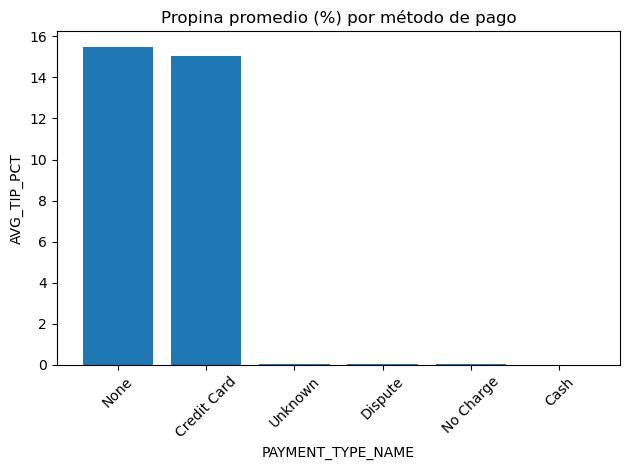

In [13]:
sql_q1 = """
SELECT payment_type_name,
       ROUND(AVG(tip_pct)*100, 2) AS avg_tip_pct,
       COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY payment_type_name
ORDER BY avg_tip_pct DESC;
"""
q1 = run_sql(sql_q1)
show_table(q1)
bar_from_df(q1, x="PAYMENT_TYPE_NAME", y="AVG_TIP_PCT",
            title="Propina promedio (%) por método de pago")


,PICKUP_BOROUGH,AVG_SPEED_MPH,TRIPS
0,None,0.000028,633755951


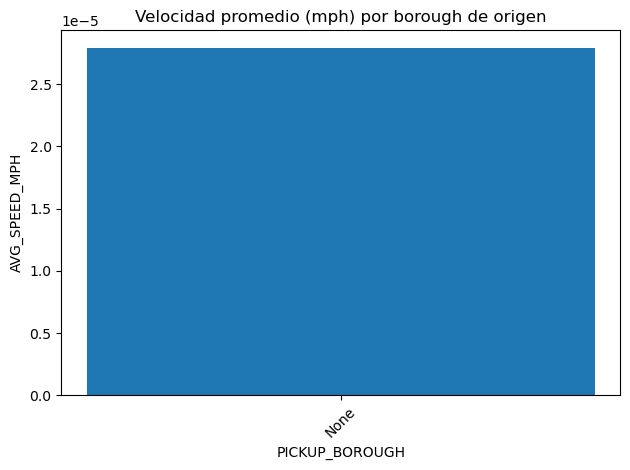

In [14]:
sql_q2 = """
SELECT pickup_borough,
       AVG(avg_speed_mph) AS avg_speed_mph,
       COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY pickup_borough
ORDER BY avg_speed_mph DESC;
"""
q2 = run_sql(sql_q2)
show_table(q2)
bar_from_df(q2, x="PICKUP_BOROUGH", y="AVG_SPEED_MPH",
            title="Velocidad promedio (mph) por borough de origen")


In [ ]:
sql_q3 = """
SELECT year, service_type, COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY year, service_type
ORDER BY year, service_type;
"""
q3 = run_sql(sql_q3)
show_table(q3)

# Gráfico por servicio en líneas separadas
for svc in sorted(q3["SERVICE_TYPE"].unique()):
    df_svc = q3[q3["SERVICE_TYPE"] == svc].sort_values("YEAR")
    line_from_df(df_svc, x="YEAR", y="TRIPS",
                 title=f"Tendencia de viajes por año — {svc}")


,YEAR,SERVICE_TYPE,TRIPS
0,31003294,yellow,1
1,31003295,yellow,2
2,31003299,yellow,1
3,31003300,yellow,1
4,31003303,yellow,1
5,31003304,yellow,2
6,31003305,yellow,1
7,31003307,yellow,2
8,31003309,yellow,1
9,31003317,yellow,1


In [ ]:
sql_q4 = """
SELECT year, service_type,
       ROUND(AVG(total_amount), 2) AS avg_ticket,
       COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY year, service_type
ORDER BY year, service_type;
"""
q4 = run_sql(sql_q4)
show_table(q4)

for svc in sorted(q4["SERVICE_TYPE"].unique()):
    df_svc = q4[q4["SERVICE_TYPE"] == svc].sort_values("YEAR")
    line_from_df(df_svc, x="YEAR", y="AVG_TICKET",
                 title=f"Ticket promedio por año — {svc}")


,DROPOFF_ZONE,TRIPS
0,None,633755951


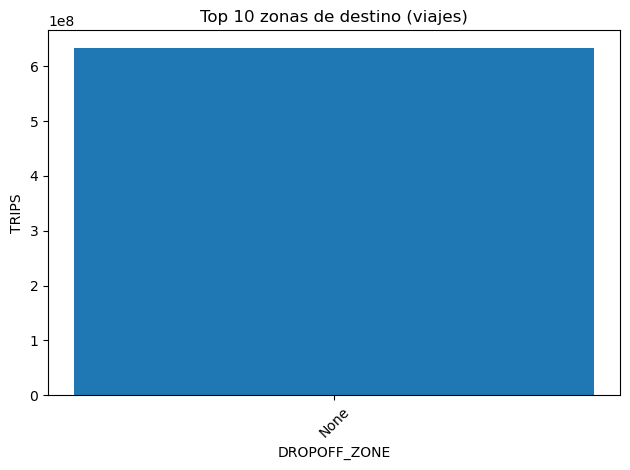

In [7]:
sql_q5 = """
SELECT dropoff_zone, COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY dropoff_zone
ORDER BY trips DESC
LIMIT 10;
"""
q5 = run_sql(sql_q5)
show_table(q5)
bar_from_df(q5, x="DROPOFF_ZONE", y="TRIPS",
            title="Top 10 zonas de destino (viajes)")


In [8]:
sql_q6 = """
SELECT year, payment_type_name,
       ROUND(AVG(tip_pct)*100, 2) AS avg_tip_pct,
       COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY year, payment_type_name
ORDER BY year, avg_tip_pct DESC;
"""
q6 = run_sql(sql_q6)
show_table(q6)

# (Opcional) gráfico agregado por año (promedio ponderado simple no mostrado aquí).
# Si deseas una línea por método, filtra por payment_type_name y grafica por año.
for p in sorted(q6["PAYMENT_TYPE_NAME"].unique()):
    df_p = q6[q6["PAYMENT_TYPE_NAME"] == p].sort_values("YEAR")
    line_from_df(df_p, x="YEAR", y="AVG_TIP_PCT",
                 title=f"Propina promedio (%) por año — {p}")


,YEAR,PAYMENT_TYPE_NAME,AVG_TIP_PCT,TRIPS
0,31003294,Cash,0.00,1
1,31003295,Credit Card,0.00,1
2,31003295,Cash,0.00,1
3,31003299,Cash,0.00,1
4,31003300,Cash,0.00,1
5,31003303,Cash,0.00,1
6,31003304,Credit Card,14.93,1
7,31003304,Cash,0.00,1
8,31003305,Cash,0.00,1
9,31003307,Credit Card,16.67,1


TypeError: '<' not supported between instances of 'NoneType' and 'str'

In [9]:
sql_q7 = """
SELECT year, pickup_borough, COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY year, pickup_borough
ORDER BY year, trips DESC;
"""
q7 = run_sql(sql_q7)
show_table(q7)

# (Opcional) Gráfico por borough (uno por uno)
for b in sorted(q7["PICKUP_BOROUGH"].dropna().unique()):
    df_b = q7[q7["PICKUP_BOROUGH"] == b].sort_values("YEAR")
    line_from_df(df_b, x="YEAR", y="TRIPS",
                 title=f"Viajes por año — Pickup borough: {b}")


,YEAR,PICKUP_BOROUGH,TRIPS
0,31003294,None,1
1,31003295,None,2
2,31003299,None,1
3,31003300,None,1
4,31003303,None,1
5,31003304,None,2
6,31003305,None,1
7,31003307,None,2
8,31003309,None,1
9,31003317,None,1


,RATE_CODE_DESC,TRIPS
0,None,633755951


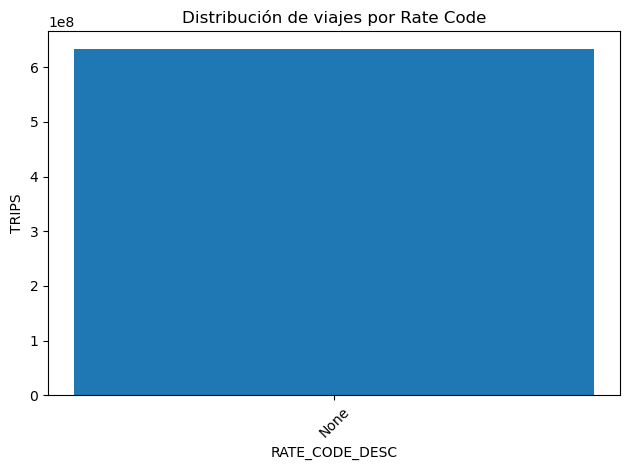

In [10]:
sql_q8 = """
SELECT rate_code_desc, COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY rate_code_desc
ORDER BY trips DESC;
"""
q8 = run_sql(sql_q8)
show_table(q8)
bar_from_df(q8, x="RATE_CODE_DESC", y="TRIPS",
            title="Distribución de viajes por Rate Code")


In [ ]:
sql_q9 = """
SELECT year, service_type,
       SUM(total_amount) AS revenue
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY year, service_type
ORDER BY year, service_type;
"""
q9 = run_sql(sql_q9)
show_table(q9)

for svc in sorted(q9["SERVICE_TYPE"].unique()):
    df_svc = q9[q9["SERVICE_TYPE"] == svc].sort_values("YEAR")
    line_from_df(df_svc, x="YEAR", y="REVENUE",
                 title=f"Ingreso total por año — {svc}")


,YEAR,SERVICE_TYPE,REVENUE
0,31003294,yellow,9.80
1,31003295,yellow,9.10
2,31003299,yellow,3.80
3,31003300,yellow,5.80
4,31003303,yellow,5.80
5,31003304,yellow,50.70
6,31003305,yellow,14.70
7,31003307,yellow,180.56
8,31003309,yellow,16.80
9,31003317,yellow,6.30


In [ ]:
sql_q10 = """
SELECT year, pickup_borough,
       AVG(trip_duration_min) AS avg_duration_min,
       COUNT(*) AS trips
FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED
GROUP BY year, pickup_borough
ORDER BY year, avg_duration_min DESC;
"""
q10 = run_sql(sql_q10)
show_table(q10)

# (Opcional) serie por borough
for b in sorted(q10["PICKUP_BOROUGH"].dropna().unique()):
    df_b = q10[q10["PICKUP_BOROUGH"] == b].sort_values("YEAR")
    line_from_df(df_b, x="YEAR", y="AVG_DURATION_MIN",
                 title=f"Duración promedio (min) por año — Pickup borough: {b}")


In [17]:
def run(sql): 
    df = session.sql(sql).to_pandas()
    df.columns = [c.lower() for c in df.columns]
    return df

print("== Conteos por capa ==")
print(run("SELECT 'RAW.TRIPS_YELLOW' AS t, COUNT(*) c FROM DB_TLC.RAW.TRIPS_YELLOW "
          "UNION ALL SELECT 'RAW.TRIPS_GREEN', COUNT(*) FROM DB_TLC.RAW.TRIPS_GREEN "
          "UNION ALL SELECT 'ANALYTICS.OBT_TRIPS', COUNT(*) FROM DB_TLC.ANALYTICS.OBT_TRIPS "
          "UNION ALL SELECT 'ANALYTICS.OBT_TRIPS_ENRICHED', COUNT(*) FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED"))

print("\n== Rango de años en OBT_TRIPS_ENRICHED ==")
print(run("SELECT MIN(year) miny, MAX(year) maxy FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED"))

print("\n== Nulos de borough en OBT_TRIPS_ENRICHED ==")
print(run("SELECT COUNT(*) total, SUM(IFF(pickup_borough IS NULL,1,0)) AS null_pickup_borough "
          "FROM DB_TLC.ANALYTICS.OBT_TRIPS_ENRICHED"))

== Conteos por capa ==
                              t          c
0              RAW.TRIPS_YELLOW  588022596
1               RAW.TRIPS_GREEN   45733355
2           ANALYTICS.OBT_TRIPS  633755951
3  ANALYTICS.OBT_TRIPS_ENRICHED  633755951

== Rango de años en OBT_TRIPS_ENRICHED ==
       miny       maxy
0  31003294  128697561

== Nulos de borough en OBT_TRIPS_ENRICHED ==
       total  null_pickup_borough
0  633755951            633755951


In [18]:
import pandas as pd, matplotlib.pyplot as plt

session.sql("ALTER SESSION SET STATEMENT_TIMEOUT_IN_SECONDS=120").collect()
session.sql("ALTER SESSION SET USE_CACHED_RESULT=TRUE").collect()

def df_sql(sql:str)->pd.DataFrame:
    df = session.sql(sql).to_pandas()
    df.columns = [c.lower() for c in df.columns]
    return df

def table_has_rows(fullname:str)->bool:
    return df_sql(f"SELECT COUNT(*) c FROM {fullname}").iloc[0,0] > 0

def plot_lines(df, x, y, group, title):
    if df.empty:
        print("⚠️ No hay filas para graficar.")
        return
    plt.figure()
    for g in sorted(df[group].dropna().unique()):
        sub = df[df[group]==g].sort_values(x)
        if sub.empty: continue
        plt.plot(sub[x].astype(str), sub[y], label=str(g))
    plt.title(title); plt.xlabel(x); plt.ylabel(y)
    plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

In [19]:
SRC = "DB_TLC.ANALYTICS.OBT_TRIPS"  # no dependemos de la columna year existente

sql_p4 = f"""
SELECT
  YEAR(pickup_datetime) AS cal_year,
  service_type,
  ROUND(AVG(IFF(total_amount BETWEEN 0 AND 1000, total_amount, NULL)), 2) AS avg_ticket,
  COUNT(*) AS trips
FROM {SRC}
WHERE pickup_datetime BETWEEN '2016-01-01' AND '2025-12-31 23:59:59'
GROUP BY cal_year, service_type
ORDER BY cal_year, service_type
"""
p4 = df_sql(sql_p4)
print(p4.shape); display(p4.head())
plot_lines(p4, x="cal_year", y="avg_ticket", group="service_type",
           title="Ticket promedio por año (2016–2025)")

(0, 4)


,cal_year,service_type,avg_ticket,trips


⚠️ No hay filas para graficar.
